# TransformerQEC: Transformer Decoder & Training

Define and train a transformer-based neural decoder for surface code quantum error correction using JAX / Flax.

**Architecture:** Pre-norm transformer encoder with CLS-token classification and physical error rate conditioning (analogous to timestep conditioning in diffusion models).

In [1]:
!pip install -q 'stim>=1.14' pymatching flax optax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 73.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.1/626.1 kB 56.3 MB/s eta 0:00:00


In [2]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from flax.training.train_state import TrainState
import optax
import numpy as np
import stim
import matplotlib.pyplot as plt
import pickle
import os
import time

print(f'JAX backend: {jax.default_backend()}')
print(f'JAX devices: {jax.devices()}')

JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


## Data Generation

In [3]:
def make_circuit(d, p, rounds=None):
    if rounds is None:
        rounds = d
    return stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        distance=d, rounds=rounds,
        before_round_data_depolarization=p,
        before_measure_flip_probability=p,
    )


def sample_syndromes(circuit, num_shots):
    sampler = circuit.compile_detector_sampler()
    det, obs = sampler.sample(num_shots, separate_observables=True)
    return det.astype(np.float32), obs[:, 0].astype(np.int64)


def generate_dataset(d, p_values, shots_per_p):
    """Generate mixed-noise-rate dataset for a given code distance."""
    all_syn, all_lab, all_p = [], [], []
    for p in p_values:
        syn, lab = sample_syndromes(make_circuit(d, p), shots_per_p)
        all_syn.append(syn)
        all_lab.append(lab)
        all_p.append(np.full(shots_per_p, p, dtype=np.float32))
    return np.concatenate(all_syn), np.concatenate(all_lab), np.concatenate(all_p)

## Model Architecture

Pre-norm transformer encoder with:
- **Token embedding:** each binary detection event $\rightarrow$ $d_{\text{model}}$-dim vector
- **Learned positional embedding:** captures spatial + temporal position
- **CLS token:** aggregates global context for classification
- **Error rate conditioning:** physical error rate $p$ broadcast-added to all tokens
- **Gradient checkpointing (`nn.remat`):** recomputes block activations during backprop instead of storing all layers â€” reduces peak VRAM from $O(\text{layers})$ to $O(1)$ in attention activations, critical for $d=7$ ($L=337$) on T4

In [4]:
class TransformerBlock(nn.Module):
    d_model: int
    num_heads: int
    ffn_dim: int

    @nn.compact
    def __call__(self, x):
        # Pre-norm multi-head self-attention
        y = nn.LayerNorm()(x)
        y = nn.MultiHeadDotProductAttention(
            num_heads=self.num_heads)(y, y)
        x = x + y
        # Pre-norm feed-forward
        y = nn.LayerNorm()(x)
        y = nn.Dense(self.ffn_dim)(y)
        y = nn.gelu(y)
        y = nn.Dense(self.d_model)(y)
        return x + y


# Gradient-checkpointed block: recomputes forward activations during
# backprop instead of caching all layers.  Reduces peak attention VRAM
# from O(num_layers * B * LÂ²) to O(B * LÂ²) â€” essential for d=7 on T4.
RematTransformerBlock = nn.remat(TransformerBlock)


class TransformerQEC(nn.Module):
    d_model: int = 64
    num_heads: int = 4
    num_layers: int = 4
    ffn_dim: int = 256
    max_seq_len: int = 400
    num_classes: int = 2

    @nn.compact
    def __call__(self, syndrome, p_error):
        B, L = syndrome.shape

        # Embed each binary detection event
        x = nn.Dense(self.d_model)(syndrome[..., None])  # (B, L, d_model)

        # Learned positional embedding
        pos = self.param('pos_embed',
            nn.initializers.normal(stddev=0.02),
            (1, self.max_seq_len, self.d_model))
        x = x + pos[:, :L]

        # Prepend learnable CLS token
        cls = self.param('cls_token',
            nn.initializers.normal(stddev=0.02),
            (1, 1, self.d_model))
        x = jnp.concatenate(
            [jnp.broadcast_to(cls, (B, 1, self.d_model)), x], axis=1)

        # Condition on physical error rate
        p_cond = nn.Dense(self.d_model)(p_error[:, None])
        p_cond = nn.gelu(p_cond)
        p_cond = nn.Dense(self.d_model)(p_cond)
        x = x + p_cond[:, None, :]  # broadcast to all tokens

        # Transformer encoder stack (gradient-checkpointed)
        for _ in range(self.num_layers):
            x = RematTransformerBlock(
                self.d_model, self.num_heads, self.ffn_dim)(x)

        # Classification head on CLS output
        h = nn.LayerNorm()(x[:, 0])
        h = nn.Dense(self.d_model)(h)
        h = nn.gelu(h)
        return nn.Dense(self.num_classes)(h)

## Training Setup

In [5]:
def cross_entropy_loss(logits, labels, num_classes=2):
    one_hot = jax.nn.one_hot(labels, num_classes)
    log_probs = jax.nn.log_softmax(logits)
    return -(one_hot * log_probs).sum(-1).mean()


def create_train_state(key, model, seq_len, num_steps, peak_lr=1e-3):
    dummy_syn = jnp.zeros((1, seq_len))
    dummy_p = jnp.zeros((1,))
    params = model.init(key, dummy_syn, dummy_p)['params']

    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0, peak_value=peak_lr,
        warmup_steps=min(500, num_steps // 10),
        decay_steps=num_steps, end_value=1e-5)
    tx = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(schedule, weight_decay=0.01))
    return TrainState.create(apply_fn=model.apply, params=params, tx=tx)


def make_epoch_fns(model, train_syn_d=None, train_lab_d=None, train_pe_d=None):
    """Build fully-JIT'd epoch functions using jax.lax.scan.

    Train function uses index-based gathering: the scan receives only
    batch indices and gathers from device-resident data arrays inside
    the loop body.  This avoids materializing a full shuffled copy of
    the dataset each epoch (~300 MB saved for d=7).

    Eval function takes pre-batched data directly (no shuffling needed).
    """

    def _train_body(state, batch_indices):
        """Gather one batch by index and take a gradient step."""
        syn = train_syn_d[batch_indices]
        lab = train_lab_d[batch_indices]
        pe  = train_pe_d[batch_indices]
        def loss_fn(params):
            logits = model.apply({'params': params}, syn, pe)
            return cross_entropy_loss(logits, lab), logits
        (loss, logits), grads = jax.value_and_grad(
            loss_fn, has_aux=True)(state.params)
        state = state.apply_gradients(grads=grads)
        acc = (logits.argmax(-1) == lab).mean()
        return state, (loss, acc)

    @jax.jit
    def train_epoch(state, index_batches):
        """Entire epoch as one compiled XLA while-loop.

        index_batches: int32 array of shape (n_batches, batch_size).
        Data is gathered from closed-over device arrays per iteration.
        """
        state, (losses, accs) = jax.lax.scan(
            _train_body, state, index_batches)
        return state, losses.mean(), accs.mean()

    @jax.jit
    def eval_epoch(params, batches):
        """Validation sweep as one compiled XLA while-loop."""
        def body(metrics, batch):
            loss_sum, acc_sum = metrics
            syn, lab, pe = batch
            logits = model.apply({'params': params}, syn, pe)
            loss = cross_entropy_loss(logits, lab)
            acc = (logits.argmax(-1) == lab).mean()
            return (loss_sum + loss, acc_sum + acc), None
        n = batches[0].shape[0]  # static during tracing
        (total_loss, total_acc), _ = jax.lax.scan(
            body, (jnp.float32(0.0), jnp.float32(0.0)), batches)
        return total_loss / n, total_acc / n

    return train_epoch, eval_epoch

## Generate Data & Initialize Model

In [6]:
# --- Configuration ---
DISTANCE = 7
P_TRAIN = [0.02, 0.03, 0.05, 0.08, 0.10]
SHOTS_PER_P = 50_000
NUM_EPOCHS = 30
SEED = 42

# Generate training and validation data
print('Generating training data...')
train_syn, train_lab, train_p = generate_dataset(
    DISTANCE, P_TRAIN, SHOTS_PER_P)
print('Generating validation data...')
val_syn, val_lab, val_p = generate_dataset(
    DISTANCE, P_TRAIN, SHOTS_PER_P // 5)

print(f'Train: {train_syn.shape[0]:,} samples, '
      f'seq_len={train_syn.shape[1]}, '
      f'error_rate={train_lab.mean():.3f}')
print(f'Val:   {val_syn.shape[0]:,} samples')

Generating training data...
Generating validation data...
Train: 250,000 samples, seq_len=336, error_rate=0.470
Val:   50,000 samples


In [7]:
# Initialize model and optimizer
seq_len = train_syn.shape[1]
model = TransformerQEC(max_seq_len=seq_len + 1)  # +1 for CLS

# Memory-aware batch sizing: attention is O(B * heads * LÂ²) per layer.
# With gradient checkpointing (remat), peak VRAM holds ~1 layer's
# activations instead of all layers.  Budget 5 GB for activations on T4.
L1 = seq_len + 1  # effective length including CLS token
bytes_per_sample = 4 * L1 * L1 * 4 * 3  # 4 heads, float32, ~3x fwd+bwd
BATCH_SIZE = min(4096, max(128, int(5_000_000_000 / bytes_per_sample)))
BATCH_SIZE = (BATCH_SIZE // 128) * 128

num_steps = (len(train_syn) // BATCH_SIZE) * NUM_EPOCHS
key = jax.random.PRNGKey(SEED)
state = create_train_state(key, model, seq_len, num_steps)

param_count = sum(p.size for p in jax.tree_util.tree_leaves(state.params))
print(f'Parameters:   {param_count:,}')
print(f'Sequence len: {seq_len}')
print(f'Batch size:   {BATCH_SIZE}')
print(f'Steps/epoch:  {len(train_syn) // BATCH_SIZE}')
print(f'Total steps:  {num_steps:,}')

Parameters:   230,402
Sequence len: 336
Batch size:   896
Steps/epoch:  279
Total steps:  8,370


## Training Loop

In [8]:
train_losses, train_accs = [], []
val_losses, val_accs = [], []

# Trim to exact batch multiples
n_train = (len(train_syn) // BATCH_SIZE) * BATCH_SIZE
n_val   = (len(val_syn) // BATCH_SIZE) * BATCH_SIZE
n_train_batches = n_train // BATCH_SIZE
n_val_batches   = n_val // BATCH_SIZE

# ---- Transfer ALL data to device ONCE ----
train_syn_d = jax.device_put(train_syn[:n_train])
train_lab_d = jax.device_put(train_lab[:n_train])
train_p_d   = jax.device_put(train_p[:n_train])

# Pre-batch validation data for scan: (n_val_batches, BATCH_SIZE, ...)
val_batches = (
    jax.device_put(val_syn[:n_val]).reshape(n_val_batches, BATCH_SIZE, seq_len),
    jax.device_put(val_lab[:n_val]).reshape(n_val_batches, BATCH_SIZE),
    jax.device_put(val_p[:n_val]).reshape(n_val_batches, BATCH_SIZE),
)

# Build epoch functions â€” train fn closes over device data arrays,
# gathers per-batch by index inside the scan body (no full-dataset copy).
train_epoch, eval_epoch = make_epoch_fns(
    model, train_syn_d, train_lab_d, train_p_d)

print(f'{n_train_batches} train batches, {n_val_batches} val batches per epoch')

# ---- Training loop ----
train_key = jax.random.PRNGKey(SEED + 1)
t0 = time.time()
for epoch in range(NUM_EPOCHS):
    # Shuffle on-device via JAX PRNG (zero host->device data transfer)
    train_key, subkey = jax.random.split(train_key)
    perm = jax.random.permutation(subkey, n_train)

    # Pass only indices â€” avoids materializing full shuffled copies
    # of syn/lab/p arrays (~300 MB saved for d=7).
    index_batches = perm.reshape(n_train_batches, BATCH_SIZE)

    # ONE call â€” entire epoch is a single compiled XLA while-loop.
    # Optimizer LR schedule advances correctly via state.step in the carry.
    state, train_loss, train_acc = train_epoch(state, index_batches)
    val_loss, val_acc = eval_epoch(state.params, val_batches)

    # Single host sync (4 scalar float() calls per epoch)
    train_losses.append(float(train_loss))
    train_accs.append(float(train_acc))
    val_losses.append(float(val_loss))
    val_accs.append(float(val_acc))

    elapsed = time.time() - t0
    tag = ' [incl. JIT compilation]' if epoch == 0 else ''
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | '
          f'train loss={train_losses[-1]:.4f} acc={train_accs[-1]:.4f} | '
          f'val loss={val_losses[-1]:.4f} acc={val_accs[-1]:.4f} | '
          f'{elapsed:.1f}s{tag}')

# Free training device arrays
del train_syn_d, train_lab_d, train_p_d

279 train batches, 55 val batches per epoch
Epoch  1/30 | train loss=0.6891 acc=0.5283 | val loss=0.6875 acc=0.5293 | 351.3s [incl. JIT compilation]
Epoch  2/30 | train loss=0.6885 acc=0.5285 | val loss=0.6879 acc=0.5307 | 683.5s
Epoch  3/30 | train loss=0.6874 acc=0.5284 | val loss=0.6863 acc=0.5296 | 1015.1s
Epoch  4/30 | train loss=0.6864 acc=0.5296 | val loss=0.6863 acc=0.5306 | 1349.0s
Epoch  5/30 | train loss=0.6853 acc=0.5304 | val loss=0.6849 acc=0.5307 | 1682.1s
Epoch  6/30 | train loss=0.6832 acc=0.5301 | val loss=0.6838 acc=0.5313 | 2017.0s
Epoch  7/30 | train loss=0.6823 acc=0.5289 | val loss=0.6832 acc=0.5319 | 2352.2s
Epoch  8/30 | train loss=0.6820 acc=0.5295 | val loss=0.6812 acc=0.5307 | 2685.4s
Epoch  9/30 | train loss=0.6811 acc=0.5296 | val loss=0.6807 acc=0.5309 | 3019.9s
Epoch 10/30 | train loss=0.6801 acc=0.5308 | val loss=0.6793 acc=0.5297 | 3354.3s
Epoch 11/30 | train loss=0.6793 acc=0.5308 | val loss=0.6826 acc=0.5306 | 3689.3s
Epoch 12/30 | train loss=0.6792 

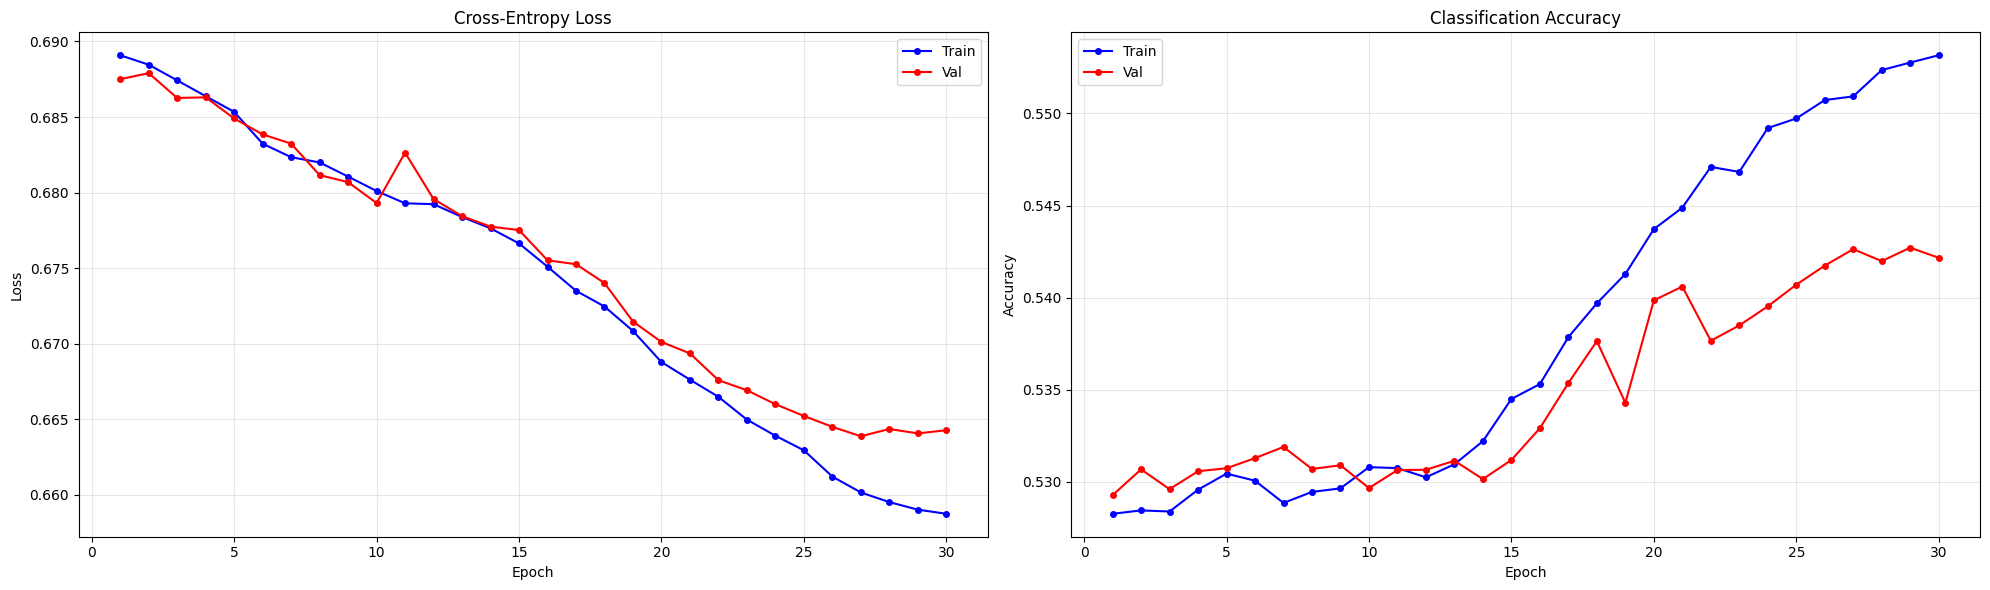

In [9]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, train_losses, 'b-o', label='Train', markersize=4)
ax1.plot(epochs, val_losses, 'r-o', label='Val', markersize=4)
ax1.set(xlabel='Epoch', ylabel='Loss', title='Cross-Entropy Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_accs, 'b-o', label='Train', markersize=4)
ax2.plot(epochs, val_accs, 'r-o', label='Val', markersize=4)
ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Classification Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save Checkpoint

In [10]:
import base64, io, pickle

checkpoint = {
    'params': jax.device_get(state.params),
    'config': {
        'distance': DISTANCE,
        'seq_len': seq_len,
        'd_model': model.d_model,
        'num_heads': model.num_heads,
        'num_layers': model.num_layers,
        'ffn_dim': model.ffn_dim,
    },
}

# Embed checkpoint as base64 in cell output.
# VSCode Colab extension saves outputs into the local .ipynb file,
# so this data persists even after the Colab VM is deleted.
# Run scripts/extract_checkpoints.py locally to decode into .pkl files.
buf = io.BytesIO()
pickle.dump(checkpoint, buf)
raw = buf.getvalue()
b64 = base64.b64encode(raw).decode('ascii')

print(f'CKPT|transformer_qec_d{DISTANCE}.pkl|{b64}')
print(f'\nCheckpoint embedded ({len(raw):,} bytes). Save notebook, then run locally:')
print('  python scripts/extract_checkpoints.py')

CKPT|transformer_qec_d7.pkl|...

Checkpoint embedded (925,601 bytes). Save notebook, then run locally:
  python scripts/extract_checkpoints.py


## Next Steps

- Train for d=3 and d=7 by changing `DISTANCE` above and re-running.
- Proceed to **03_evaluation.ipynb** for MWPM comparison and threshold analysis.
- Experiment with model size, learning rate, or training noise rates.